# Example: Gaussian Bootstrap Uncertainty in Single Index Models
The lecture gave classical standard errors and 95% confidence intervals for the single index model (SIM) parameters. How much might alpha and beta change if we had another dataset?

> __Learning Objectives:__
>
> By the end of this example, you should be able to:
>
> * __Estimate SIM parameters with confidence intervals:__ Use ordinary least squares regression to compute alpha and beta for every firm in the dataset. Compute their standard errors and 95% confidence intervals.
> * __Evaluate the fit:__ Compute R-squared to measure how much of a firm's growth-rate variance the market index explains. Compare the fitted and observed growth rates in a plot.
> * __Quantify parameter uncertainty by simulation:__ Generate synthetic datasets from a normal distribution fitted to the residuals, and refit alpha and beta on each one. Compare the spread of the refitted values with the classical standard errors and intervals.

In this example, we fit the SIM for every firm, then use a Gaussian bootstrap to check the classical intervals for one firm.

Let's get started!

___

## Setup, Data, and Prerequisites
First, we load the local [`Include.jl`](Include.jl) setup file and its required packages.

> __Include:__ The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates [`Include.jl`](Include.jl) in the notebook's global scope. The setup file activates the course project, defines local paths, and loads the packages used here.

Let's set up our code environment:

In [1]:
include(joinpath(@__DIR__, "Include.jl")); # load the local notebook setup

See the [Julia documentation](https://docs.julialang.org/en/v1/) and the [CHEME 5660 Quantitative Finance Package documentation](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/) for the functions and types used here.

### Data
The dataset contains daily open-high-low-close (OHLC) records for firms in the [S&P 500](https://en.wikipedia.org/wiki/S%26P_500) from January 3, 2014 through December 31, 2024, along with records for several exchange-traded funds and volatility products.

We use each day's volume-weighted average price (VWAP) as our price observation. It averages transaction prices using the number of shares traded as weights. These observations are stored in the `volume_weighted_average_price` column.

Let's load the data using [the `MyTrainingMarketDataSet()` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/data/#VLQuantitativeFinancePackage.MyTrainingMarketDataSet). We store the result in `original_dataset`, a dictionary whose keys are ticker symbols and whose values are `DataFrame` tables containing each ticker's price history.

In [2]:
original_dataset = MyTrainingMarketDataSet() |> x-> x["dataset"]; # ticker => historical price table

Not all tickers have the same number of price observations. For example, a firm may have been listed after the dataset begins or delisted before it ends. We will use `AAPL` as our reference and retain tickers with the same number of daily records.

First, let's count the records for `AAPL` and save that value in `maximum_number_trading_days::Int64`:

In [3]:
maximum_number_trading_days = original_dataset["AAPL"] |> nrow; # reference number of daily price records

Now, let's iterate through our data and collect tickers with `maximum_number_trading_days` records. We store the resulting dataset $\mathcal{D}$ in `dataset::Dict{String,DataFrame}`:

In [4]:
dataset = let

    # Initialize the retained price histories -
    dataset = Dict{String, DataFrame}();

    # Retain tickers with the same number of records as AAPL -
    for (ticker, data) ∈ original_dataset # each entry unpacks into (key, value), in no fixed order
        if (nrow(data) == maximum_number_trading_days)
            dataset[ticker] = data;
        end
    end
    dataset; # a let block returns its last expression
end;

Finally, let's get a list of the firms in our cleaned dataset and sort them alphabetically. We store the sorted firm ticker symbols in the `list_of_tickers::Array{String,1}` variable:

In [5]:
list_of_tickers = keys(dataset) |> collect |> sort; # alphabetical order used by the growth-matrix columns

### Constants
Let's set some constants that we'll use in this study. See the comment next to each constant for its definition and units. You can change `ticker_of_interest` to any ticker in `list_of_tickers`.

In [6]:
# Set the time unit, the market index, the firm we study, and the bootstrap size -
Δt = (1.0/252.0); # time step (1 trading day, in years)
market_ticker = "SPY"; # the SPDR S&P 500 ETF is our proxy for the market index M
ticker_of_interest = "MSFT"; # the firm we examine in Tasks 1 to 3 (try another ticker)
number_of_bootstrap_samples = 1000; # number of synthetic datasets K

___

## Task 1: Fit Single Index Models for All Firms
In this task, we fit the single index model for every firm in the dataset and compute the classical 95% confidence intervals for alpha and beta. We then measure how well the model fits the selected firm.

First, we compute the growth-rate matrix using [the `log_growth_matrix(...)` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/equity/#VLQuantitativeFinancePackage.log_growth_matrix). Each row is a trading day and each column is a firm in `list_of_tickers`, in units of inverse years. The function pairs prices by row position, so we also check that every firm shares the market's trading dates. We store the result in `growth_rate_array::Array{Float64,2}`:

In [7]:
growth_rate_array = let

    # Check that every firm shares the market's trading dates -
    # log_growth_matrix pairs prices by row position. @assert stops the cell if a check is false.
    for ticker ∈ list_of_tickers
        @assert dataset[ticker].timestamp == dataset[market_ticker].timestamp
    end

    # Compute the growth rates, one row per trading day and one column per ticker (1/yr) -
    # Δt = Δt passes our Δt as a keyword argument. The risk-free rate keeps its default of zero.
    log_growth_matrix(dataset, list_of_tickers, Δt = Δt); # a let block returns its last expression
end;

Next, we pull out the market growth rates, the `market_ticker` column, and store them in `Gₘ::Array{Float64,1}`. Every firm shares the design matrix $\hat{\mathbf{X}}$ from the lecture: a column of ones for the intercept and a column of market growth rates. We store it in `X̂::Array{Float64,2}`:

In [8]:
# Pull out the market column and build the shared design matrix -
Gₘ = growth_rate_array[:, findfirst(==(market_ticker), list_of_tickers)]; # market growth rates (1/yr); ==(x) means y -> y == x
@assert var(Gₘ) > 0 # the market column must vary for an identifiable slope
X̂ = [ones(length(Gₘ)) Gₘ]; # N × 2 design matrix: a column of ones, then the market growth rates

Now, let's fit the model for every firm. For firm $i$, [the backslash operator](https://docs.julialang.org/en/v1/stdlib/LinearAlgebra/) solves the least-squares problem `X̂ \ yᵢ` for $\hat{\alpha}_{i}$ and $\hat{\beta}_{i}$. We then compute the lecture's residual variance and standard errors. With thousands of observations, the 95% confidence interval for each parameter $\hat{\theta}$ is given by:

$$
\hat{\theta}\pm z_{0.975}\,\text{SE}(\hat{\theta})
$$

where $z_{0.975}\approx1.96$ is the 97.5th percentile of the standard normal distribution. We store each firm's results in `parameters_theory_dict::Dict{String, NamedTuple}`, keyed by ticker:

In [9]:
parameters_theory_dict = let

    # Initialize -
    N = size(X̂, 1); # number of daily growth-rate observations
    p = 2; # number of estimated parameters (α and β)
    z = quantile(Normal(), 0.975); # 95% two-sided critical value, about 1.96
    XtX_inv = (transpose(X̂)*X̂) \ I; # (X̂ᵀX̂)⁻¹ by a solve against the identity, the same for every firm
    data = Dict{String, NamedTuple}(); # results, keyed by ticker

    # Fit each firm and compute its classical standard errors -
    for (i, ticker) ∈ enumerate(list_of_tickers) # enumerate yields (column index, ticker) pairs
        yᵢ = growth_rate_array[:, i]; # firm i's growth rates (1/yr)
        θ̂ᵢ = X̂ \ yᵢ; # least-squares estimates [α̂ᵢ, β̂ᵢ]
        rᵢ = yᵢ .- X̂*θ̂ᵢ; # residuals (1/yr)
        s² = norm(rᵢ)^2/(N - p); # residual growth-rate variance (1/yr²)
        SEᵢ = sqrt.(s² .* diag(XtX_inv)); # standard errors [SE(α̂ᵢ) in 1/yr, SE(β̂ᵢ)]

        # Save the estimates, standard errors, and 95% intervals as a named tuple -
        data[ticker] = (
            alpha = θ̂ᵢ[1],
            beta = θ̂ᵢ[2],
            alpha_SE = SEᵢ[1],
            beta_SE = SEᵢ[2],
            alpha_95_CI_lower = θ̂ᵢ[1] - z*SEᵢ[1],
            alpha_95_CI_upper = θ̂ᵢ[1] + z*SEᵢ[1],
            beta_95_CI_lower = θ̂ᵢ[2] - z*SEᵢ[2],
            beta_95_CI_upper = θ̂ᵢ[2] + z*SEᵢ[2],
            training_variance = s²
        );
    end
    data; # return the dictionary
end;

Let's display the estimates, standard errors, and 95% intervals for `ticker_of_interest` using [the `pretty_table(...)` function](https://ronisbr.github.io/PrettyTables.jl/stable/lib/library/#PrettyTables.pretty_table):

In [10]:
let
    # Collect the selected firm's two parameters into a table, one row per parameter -
    params = parameters_theory_dict[ticker_of_interest];
    df = DataFrame(
        parameter = ["α (1/yr)", "β"],
        estimate = [params.alpha, params.beta],
        SE = [params.alpha_SE, params.beta_SE],
        CI_lower = [params.alpha_95_CI_lower, params.beta_95_CI_lower],
        CI_upper = [params.alpha_95_CI_upper, params.beta_95_CI_upper]
    );

    # Display the table with four decimal places in the numeric columns -
    pretty_table(df, backend = :text, formatters = [fmt__printf("%.4f", [2, 3, 4, 5])],
        table_format = TextTableFormat(borders = text_table_borders__compact))
end

 ----------- ---------- --------- ---------- ----------
  parameter   estimate        SE   CI_lower   CI_upper 
     String    Float64   Float64    Float64    Float64 
 ----------- ---------- --------- ---------- ----------
   α (1/yr)     0.0999    0.0450     0.0117     0.1882
          β     1.1520    0.0210     1.1109     1.1931
 ----------- ---------- --------- ---------- ----------


Compare each interval with its estimate. Does the alpha interval contain zero? How wide is the beta interval? Next, let's look across all firms, excluding `market_ticker` itself. We count the firms whose 95% interval contains zero:

In [11]:
let
    # Every firm except the market index, whose fit to itself is exact -
    firms = filter(!=(market_ticker), list_of_tickers); # !=(x) means y -> y != x
    fits = [parameters_theory_dict[ticker] for ticker ∈ firms];

    # Count the 95% intervals that contain zero -
    # count(f, v) counts the entries of v for which f returns true.
    α_zero = count(q -> q.alpha_95_CI_lower ≤ 0 ≤ q.alpha_95_CI_upper, fits);
    β_zero = count(q -> q.beta_95_CI_lower ≤ 0 ≤ q.beta_95_CI_upper, fits);

    # Display the counts -
    df = DataFrame(parameter = ["α", "β"], firms = [length(firms), length(firms)], CI_contains_zero = [α_zero, β_zero]);
    pretty_table(df, backend = :text, table_format = TextTableFormat(borders = text_table_borders__compact))
end

 ----------- ------- ------------------
  parameter   firms   CI_contains_zero 
     String   Int64              Int64 
 ----------- ------- ------------------
          α     423                373
          β     423                  1
 ----------- ------- ------------------


__What do we see?__ Most alpha intervals contain zero, so for most firms we cannot tell the intercept apart from zero. Almost no beta interval contains zero.

### How well does the market explain the selected firm?
The coefficient of determination $R^{2}$ is the fraction of the firm's growth-rate variation that the market term explains. From the lecture, it is given by:

$$
R^{2} = 1-\frac{\lVert\mathbf{r}\rVert_{2}^{2}}{\sum_{t=1}^{N}\left(g_{i,t}-g^{\prime}_{i}\right)^{2}}
$$

where $\mathbf{r}$ is the residual vector and $g^{\prime}_{i}$ is the firm's sample-mean growth rate. A value near one means the market explains most of the variation. A value near zero means the residual dominates. We also keep the firm's observed and fitted growth rates in `y_firm` and `ŷ_firm` for the plot and the bootstrap:

In [12]:
R², y_firm, ŷ_firm = let

    # Get the selected firm's observed and fitted growth rates -
    i = findfirst(==(ticker_of_interest), list_of_tickers); # column of the selected firm
    params = parameters_theory_dict[ticker_of_interest]; # estimates from Task 1
    yᵢ = growth_rate_array[:, i]; # observed growth rates (1/yr)
    ŷᵢ = X̂*[params.alpha, params.beta]; # fitted growth rates α̂ + β̂ g_M (1/yr)

    # Compare the residual and total sums of squares -
    SS_residual = sum((yᵢ .- ŷᵢ).^2); # ‖r‖², the variation the market term does not explain
    SS_total = sum((yᵢ .- mean(yᵢ)).^2); # variation around the sample mean
    R² = 1 - SS_residual/SS_total;
    @assert isapprox(R², cor(yᵢ, Gₘ)^2) # with an intercept, R² is the squared correlation

    (R², yᵢ, ŷᵢ); # this tuple unpacks, in order, into the three names on the first line
end;
R² # display the coefficient of determination

0.5218895057979187

Let's plot the observed growth rates against the fitted ones. Points on the dashed line are fitted exactly. A point's height above or below the line is its residual:

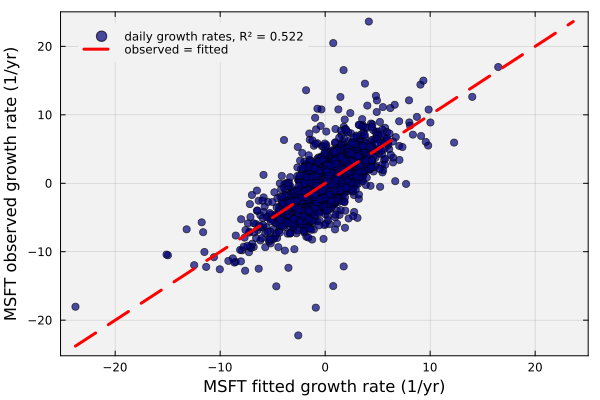

In [13]:
let
    # Set the line's end points from the smallest and largest value on either axis -
    xy_line = collect(extrema(vcat(ŷ_firm, y_firm))); # extrema returns (min, max)

    # Plot observed against fitted growth rates, with the line where they are equal -
    scatter(ŷ_firm, y_firm, color = :navy, markersize = 4, alpha = 0.7, label = "daily growth rates, R² = $(round(R², digits = 3))")
    plot!(xy_line, xy_line, color = :red, linestyle = :dash, lw = 3, label = "observed = fitted")
    plot!(bg = "gray95", background_color_outside = "white", framestyle = :box, fg_legend = :transparent, legend = :topleft)
    xlabel!("$(ticker_of_interest) fitted growth rate (1/yr)")
    ylabel!("$(ticker_of_interest) observed growth rate (1/yr)")
end

___

## Task 2: Generate Bootstrap Estimates
In this task, we generate synthetic datasets for the selected firm from the fitted model and refit alpha and beta on each one.

> __What is a Gaussian bootstrap?__ A bootstrap estimates the spread of a statistic by recomputing it on many simulated datasets. In a Gaussian bootstrap, we draw each dataset's residuals from a normal distribution fitted to the observed residuals. The market growth rates stay the same in every dataset.

We follow the lecture's pseudocode:

__Initialization:__ Given the design matrix $\hat{\mathbf{X}}$, the estimates $\hat{\boldsymbol{\theta}}_{i}$, the residuals $\mathbf{r}$, and the number of samples $K$, fit a normal distribution to the residuals.

For each $k=1,2,\dots,K$ __do__:
1. Draw synthetic residuals $\boldsymbol{\varepsilon}^{(k)}$ from the fitted normal distribution.
2. Create synthetic observations: $\mathbf{y}^{(k)}\gets\hat{\mathbf{X}}\hat{\boldsymbol{\theta}}_{i}+\boldsymbol{\varepsilon}^{(k)}$.
3. Estimate parameters from the synthetic observations: $\hat{\boldsymbol{\theta}}^{(k)}\gets\left(\hat{\mathbf{X}}^{\top}\hat{\mathbf{X}}\right)^{-1}\hat{\mathbf{X}}^{\top}\mathbf{y}^{(k)}$.

Compare the spread of $\hat{\boldsymbol{\theta}}^{(1)},\dots,\hat{\boldsymbol{\theta}}^{(K)}$ with the standard errors.

Let's generate the synthetic datasets. We fit the normal distribution with [the `fit_mle(...)` function](https://juliastats.org/Distributions.jl/stable/fit/#Distributions.fit_mle-Tuple{Any,%20Any}) and store one dataset per column of `synthetic_datasets::Array{Float64,2}`:

In [14]:
synthetic_datasets = let

    # Fit a normal distribution to the selected firm's residuals -
    r = y_firm .- ŷ_firm; # residuals r (1/yr)
    d = fit_mle(Normal, r); # maximum-likelihood fit: μ = mean(r) ≈ 0, σ = std(r, corrected = false)
    N = length(y_firm); # number of daily observations
    rng = MersenneTwister(5660); # seeded random number generator, so every run gives the same draws

    # Build each synthetic dataset from the fitted growth rates plus new residuals -
    synthetic_datasets = Array{Float64,2}(undef, N, number_of_bootstrap_samples); # one column per dataset
    for k ∈ 1:number_of_bootstrap_samples
        ε = rand(rng, d, N); # synthetic residuals ε⁽ᵏ⁾ (1/yr)
        synthetic_datasets[:, k] = ŷ_firm .+ ε; # y⁽ᵏ⁾ = X̂θ̂ + ε⁽ᵏ⁾
    end
    synthetic_datasets; # return
end;

Next, we refit the model to each synthetic dataset with the same design matrix. We store the estimates in `synthetic_parameter_array::Array{Float64,2}`, with $\hat{\alpha}^{(k)}$ in row 1 and $\hat{\beta}^{(k)}$ in row 2 of column $k$:

In [15]:
synthetic_parameter_array = let

    # Refit α and β to each synthetic dataset -
    K = size(synthetic_datasets, 2); # number of synthetic datasets
    synthetic_parameter_array = Array{Float64,2}(undef, 2, K); # row 1: α̂⁽ᵏ⁾ (1/yr), row 2: β̂⁽ᵏ⁾
    for k ∈ 1:K
        synthetic_parameter_array[:, k] = X̂ \ synthetic_datasets[:, k]; # least squares, as in Task 1
    end
    # Hmmm. X̂ \ synthetic_datasets gives the same estimates (up to rounding) in one line. Why does that work?

    synthetic_parameter_array; # return
end

2×1000 Matrix{Float64}:
 0.132421  0.0910816  0.0675919  0.0525265  …  0.102809  0.102451  0.0909018
 1.15983   1.16378    1.13103    1.15627       1.14278   1.14756   1.16336

___

## Task 3: Compare Bootstrap and Classical Uncertainty
In this task, we compare the spread of the bootstrap estimates with the classical standard errors and 95% intervals from Task 1.

> __What do we expect to see?__ The synthetic datasets follow the fitted Gaussian model. The bootstrap standard errors should match the classical ones up to the sampling error of $K$ draws, about 2% for $K=1000$. Agreement checks the calculation. Residual diagnostics test the model's assumptions.

The bootstrap standard error of each parameter is the standard deviation of its $K$ refitted values. Let's compare it with the classical standard error, and count the refits that land inside the classical 95% interval:

In [16]:
let
    # Classical results from Task 1 for the selected firm -
    params = parameters_theory_dict[ticker_of_interest];
    SE_classical = [params.alpha_SE, params.beta_SE]; # [SE(α̂) (1/yr), SE(β̂)]
    lower = [params.alpha_95_CI_lower, params.beta_95_CI_lower]; # classical 95% interval, lower ends
    upper = [params.alpha_95_CI_upper, params.beta_95_CI_upper]; # classical 95% interval, upper ends

    # Bootstrap standard errors: the standard deviation across each row of refits -
    SE_bootstrap = vec(std(synthetic_parameter_array, dims = 2)); # dims = 2 works across the K columns

    # Fraction of refits inside the classical interval, one parameter at a time -
    # The comparison gives a vector of true/false values, and its mean is the fraction that is true.
    inside = [mean(lower[j] .≤ synthetic_parameter_array[j, :] .≤ upper[j]) for j ∈ 1:2];

    # Display the comparison -
    df = DataFrame(
        parameter = ["α (1/yr)", "β"],
        SE_classical = SE_classical,
        SE_bootstrap = SE_bootstrap,
        ratio = SE_bootstrap ./ SE_classical,
        inside_classical_CI = inside
    );
    pretty_table(df, backend = :text, formatters = [fmt__printf("%.4f", [2, 3]), fmt__printf("%.3f", [4, 5])],
        table_format = TextTableFormat(borders = text_table_borders__compact))
end

 ----------- -------------- -------------- --------- ---------------------
  parameter   SE_classical   SE_bootstrap     ratio   inside_classical_CI 
     String        Float64        Float64   Float64               Float64 
 ----------- -------------- -------------- --------- ---------------------
   α (1/yr)         0.0450         0.0457     1.014                 0.945
          β         0.0210         0.0207     0.988                 0.953
 ----------- -------------- -------------- --------- ---------------------


__What do we see?__ Both ratios are within a few percent of one, and about 95% of the refits land inside each classical interval.

Let's look at the refits themselves. Each panel compares the histogram of the $K$ refitted values with the classical normal distribution and 95% interval:

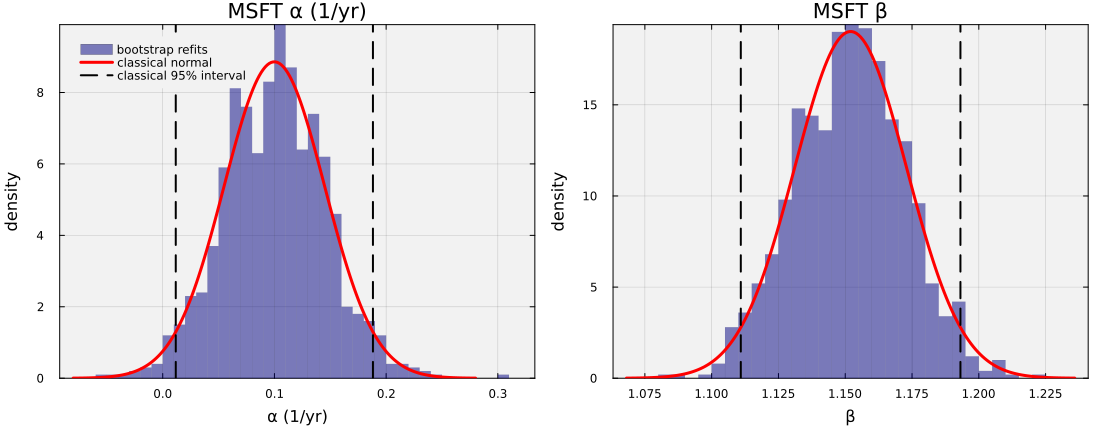

In [17]:
let
    # Classical estimates and standard errors for the selected firm -
    params = parameters_theory_dict[ticker_of_interest];
    θ̂ = [params.alpha, params.beta]; # estimates from Task 1
    SE = [params.alpha_SE, params.beta_SE]; # classical standard errors
    z = quantile(Normal(), 0.975); # 95% critical value, about 1.96
    labels = ["α (1/yr)", "β"];

    # One panel per parameter -
    panels = [];
    for j ∈ 1:2
        x = range(θ̂[j] - 4*SE[j], θ̂[j] + 4*SE[j], length = 200); # ±4 SE around the estimate
        p = histogram(synthetic_parameter_array[j, :], bins = 40, normalize = :pdf, color = :navy, alpha = 0.5, lw = 0,
            label = "bootstrap refits");
        plot!(p, x, pdf.(Normal(θ̂[j], SE[j]), x), color = :red, lw = 3, label = "classical normal"); # pdf. evaluates the density at every x
        vline!(p, [θ̂[j] - z*SE[j], θ̂[j] + z*SE[j]], color = :black, linestyle = :dash, lw = 2, label = "classical 95% interval");
        plot!(p, title = "$(ticker_of_interest) $(labels[j])", xlabel = labels[j], ylabel = "density",
            legend = (j == 1 ? :topleft : false)); # condition ? a : b picks a when true: only the first panel gets a legend
        push!(panels, p);
    end

    # Draw the two panels side by side -
    plot(panels..., layout = (1, 2), size = (1100, 430), bg = "gray95", background_color_outside = "white",
        framestyle = :box, fg_legend = :transparent, left_margin = 5Plots.mm, bottom_margin = 5Plots.mm) # panels... splats the vector into arguments
end

__So how much might alpha and beta change with another dataset?__ About two standard errors either way, since 95% of the refits stay inside the classical interval. Across all firms (Task 1), that means another dataset could flip the sign of most alphas, but almost never the sign of beta.

___

## Summary
In this example, we fit single index models for every firm, measured the fit for one firm, and checked its standard errors with a Gaussian bootstrap.

> __Key Takeaways:__
>
> * __Parameter estimates and intervals:__ We fit alpha and beta for every firm by least squares and computed their classical 95% confidence intervals. Most alpha intervals contained zero, but almost no beta interval did.
> * __Goodness of fit:__ We used R-squared to measure the fraction of a firm's growth-rate variance that the market index explains. It equals the squared correlation between the firm's and the market's growth rates.
> * __Uncertainty by simulation:__ We refit alpha and beta on synthetic datasets from the fitted Gaussian model and compared their spread with the classical standard errors. The two agreed within the bootstrap's sampling error, which checks the calculation but not the model's assumptions.

The [extended diagnostics example](advanced/diagnostics/CHEME-5660-L6b-Advanced-SIM-Diagnostics-Fall-2026.ipynb) compares this bootstrap with one that resamples the observed residuals and checks the residuals for dependence across days.

___

## Disclaimer and Risks

__This content is offered solely for training and informational purposes__. No offer or solicitation to buy or sell securities or derivative products or any investment or trading advice or strategy is made, given, or endorsed by the teaching team.

__Trading involves risk__. Carefully review your financial situation before investing in securities, futures contracts, options, or commodity interests. Past performance, whether actual or indicated by historical tests of strategies, is no guarantee of future performance or success. Trading is generally inappropriate for someone with limited resources, investment or trading experience, or a low-risk tolerance. Only risk capital that is not required for living expenses.

__You are fully responsible for any investment or trading decisions you make__. Such decisions should be based solely on evaluating your financial circumstances, investment or trading objectives, risk tolerance, and liquidity needs.